In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Dict, Tuple, List, Optional

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


def make_unique_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    If there are duplicate column names (e.g., 'left' repeated),
    keep the first occurrence as-is and suffix the rest.
    """
    cols = list(df.columns)
    seen = {}
    new_cols = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            new_cols.append(c)
        else:
            seen[c] += 1
            new_cols.append(f"{c}_{seen[c]}")
    df.columns = new_cols
    return df

def load_data(csv_path: str) -> pd.DataFrame:
    """
    Load the dataset from a CSV file.
    """
    df = pd.read_csv(csv_path)
    df = make_unique_columns(df)
    return df
   
def basic_data_info(df: pd.DataFrame) -> None:
    """
    Display basic information about the DataFrame.
    """
    print(df.info())
    print(df.head())

def basic_data_quality_report(df: pd.DataFrame, target: str = "left") -> Dict[str, object]:
    """Providing a basic data quality report."""
    report = {
        "shape": df.shape,
        "dtypes": df.dtypes,
        "missing_per_col": df.isnull().sum(),
        "duplicate_rows": int(df.duplicated().sum()),
    }

    if target in df.columns:
        report["class_balance"] = df[target].value_counts(dropna=False)
        report["class_ratio"] = df[target].value_counts(normalize=True, dropna=False)

    print("Shape:", report["shape"])
    print("\nMissing values per column:\n", report["missing_per_col"])
    print("\nDuplicate rows:", report["duplicate_rows"])
    if "class_balance" in report:
        print("\nClass balance (left):\n", report["class_balance"])
        print("\nClass ratio (left):\n", report["class_ratio"])

    return report



In [98]:
def plot_correlation_heatmap(df: pd.DataFrame, numeric_cols: Optional[List[str]] = None) -> None:
    """
    Plotting correlation heatmap for numerical columns).
    """
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    corr = df[numeric_cols].corr(numeric_only=True)

    plt.figure(figsize=(12, 8))
    plt.imshow(corr.values, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.tight_layout()
    plt.show()

In [99]:
# ------------------------------------------------------------
# Distribution Plots for:
#    satisfaction_level, last_evaluation, average_montly_hours
# ----------
def plot_distributions(df: pd.DataFrame) -> None:
    cols = ["satisfaction_level", "last_evaluation", "average_montly_hours"]
    existing = [c for c in cols if c in df.columns]
    if not existing:
        print("None of the required distribution columns found:", cols)
        return

    for col in existing:
        plt.figure(figsize=(8, 4))
        plt.hist(df[col].dropna(), bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()


In [101]:
def plot_projects_left_bar(df: pd.DataFrame, target: str = "left") -> None:
    if "number_project" not in df.columns or target not in df.columns:
        print("Required columns missing: number_project and/or", target)
        return

    # Force target to be 1D safely
    left_s = get_1d_col(df, target)

    # Average number_project by left/stayed
    grouped = (
        pd.DataFrame({"left": left_s, "number_project": df["number_project"]})
        .groupby("left")["number_project"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(6, 4))
    plt.bar(grouped["left"].astype(str), grouped["number_project"])
    plt.title("Average number_project by Employee Status (left)")
    plt.xlabel("left (0=Stayed, 1=Left)")
    plt.ylabel("Avg number_project")
    plt.tight_layout()
    plt.show()

    #Count of employees by number_project and left/stayed
    tmp = pd.DataFrame({"number_project": df["number_project"], "left": left_s})
    counts = tmp.groupby(["number_project", "left"]).size().unstack(fill_value=0).sort_index()

    plt.figure(figsize=(10, 5))
    x = np.arange(len(counts.index))
    width = 0.35

    stayed = counts.get(0, pd.Series(0, index=counts.index))
    leavers = counts.get(1, pd.Series(0, index=counts.index))

    plt.bar(x - width/2, stayed.values, width, label="Stayed (left=0)")
    plt.bar(x + width/2, leavers.values, width, label="Left (left=1)")
    plt.xticks(x, counts.index)
    plt.title("Count of Employees by number_project (Stayed vs Left)")
    plt.xlabel("number_project")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()



In [102]:
def cluster_leavers_kmeans(
    df: pd.DataFrame,
    target: str = "left",
    n_clusters: int = 3,
    random_state: int = 123
) -> pd.DataFrame:
    """
    Fit KMeans clustering on employees who left based on
    satisfaction_level and last_evaluation.
    Returns leavers dataframe with 'cluster' column.
    """
    required = ["satisfaction_level", "last_evaluation", target]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")

    leavers = df[df[target] == 1].copy()
    X = leavers[["satisfaction_level", "last_evaluation"]].dropna()

    # Kmeans clustering generally benefits from scaling
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = km.fit_predict(Xs)

    leavers.loc[X.index, "cluster"] = labels

    # Plot clusters
    plt.figure(figsize=(7, 5))
    for cl in range(n_clusters):
        pts = leavers[leavers["cluster"] == cl]
        plt.scatter(pts["satisfaction_level"], pts["last_evaluation"], s=12, label=f"Cluster {cl}")
    plt.title("Clusters of Employees Who Left (KMeans, k=3)")
    plt.xlabel("satisfaction_level")
    plt.ylabel("last_evaluation")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Cluster summary
    summary = leavers.groupby("cluster")[["satisfaction_level", "last_evaluation"]].mean()
    print("\nCluster Means (Leavers):\n", summary)

    return leavers


In [103]:
def preprocess_one_hot(
    df: pd.DataFrame,
    target: str = "left",
    drop_cols: Optional[List[str]] = None
) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separating X/y. One-hot encode categorical columns using get_dummies, combine with numeric.
    """
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found.")

    df2 = df.copy()
    if drop_cols:
        df2 = df2.drop(columns=drop_cols, errors="ignore")

    y = df2[target].astype(int)
    X = df2.drop(columns=[target])

    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = X.columns.difference(cat_cols).tolist()

    X_cat = pd.get_dummies(X[cat_cols], drop_first=False) if cat_cols else pd.DataFrame(index=X.index)
    X_num = X[num_cols].copy()

    X_final = pd.concat([X_num, X_cat], axis=1)
    return X_final, y


In [105]:
def split_stratified(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.2,
    random_state: int = 123
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
   Stratified train-test(80:20) split to maintain class distribution.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    return X_train, X_test, y_train, y_test


In [106]:
def build_models(random_state: int = 123) -> Dict[str, object]:
    """
    Return a dictionary of classification models to evaluate.
    """
    models = {
        "logreg": LogisticRegression(max_iter=2000, random_state=random_state),
        "random_forest": RandomForestClassifier(
            n_estimators=300, random_state=random_state, n_jobs=-1
        ),
        "grad_boost": GradientBoostingClassifier(random_state=random_state),
    }
    return models


In [107]:
def cross_validate_with_smote(
    models: Dict[str, object],
    X_train: pd.DataFrame,
    y_train: pd.Series,
    random_state: int = 123,
    cv_splits: int = 5
) -> pd.DataFrame:
    """
   For each model, performing Stratified K-Fold CV with SMOTE applied within each fold.
   Returns a DataFrame summarizing mean scores across folds for each model.
    """
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    rows = []
    for name, model in models.items():
        pipe = ImbPipeline(steps=[
            ("smote", SMOTE(random_state=random_state)),
            ("model", model)
        ])

        # Using multiple scoring metrics and then choosing best later
        scoring = {
            "roc_auc": "roc_auc",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "accuracy": "accuracy",
        }

        cv_out = cross_validate(
            pipe, X_train, y_train,
            cv=skf,
            scoring=scoring,
            return_train_score=False
        )

        row = {"model": name}
        for k, v in cv_out.items():
            if k.startswith("test_"):
                row[k.replace("test_", "")] = float(np.mean(v))
        rows.append(row)

    results = pd.DataFrame(rows).sort_values(by="roc_auc", ascending=False)
    print("\n5-Fold CV (with SMOTE inside folds) — Mean Scores:\n", results)
    return results


In [ ]:
def fit_models_with_smote(
    models: Dict[str, object],
    X_train: pd.DataFrame,
    y_train: pd.Series,
    random_state: int = 123
) -> Dict[str, ImbPipeline]:
    """
    Fitting models on the full training data with SMOTE.
    Returns a dictionary of fitted pipelines.
    """
    fitted = {}
    for name, model in models.items():
        pipe = ImbPipeline(steps=[
            ("smote", SMOTE(random_state=random_state)),
            ("model", model)
        ])
        pipe.fit(X_train, y_train)
        fitted[name] = pipe
    return fitted

In [108]:
def evaluate_models(
    fitted_models: Dict[str, ImbPipeline],
    X_test: pd.DataFrame,
    y_test: pd.Series
) -> pd.DataFrame:
    """
    Evaluating fitted models on the test set.
    Printing ROC AUC, confusion matrix, classification report.
    Plotting ROC curves.
    Returning dataframe of key test metrics (ROC AUC, etc.). Also plotting ROC curves and prints confusion matrices + classification reports.
    """
    metrics_rows = []

    # ROC plot
    plt.figure(figsize=(8, 6))

    for name, pipe in fitted_models.items():
        # Predicting probabilities for ROC/AUC 
        if hasattr(pipe, "predict_proba"):
            y_prob = pipe.predict_proba(X_test)[:, 1]
        else:
            # Fallback for models without predict_proba
            y_prob = pipe.decision_function(X_test)

        y_pred = pipe.predict(X_test)

        auc = roc_auc_score(y_test, y_prob)
        cm = confusion_matrix(y_test, y_pred)

        print("\n" + "=" * 70)
        print(f"MODEL: {name}")
        print("ROC AUC:", round(auc, 4))
        print("\nConfusion Matrix:\n", cm)
        print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

        metrics_rows.append({
            "model": name,
            "roc_auc": float(auc),
            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        })

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title("ROC Curves (Test Set)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

    metrics_df = pd.DataFrame(metrics_rows).sort_values("roc_auc", ascending=False)
    print("\nTest Metrics Summary:\n", metrics_df)
    return metrics_df

In [111]:
def choose_best_model(metrics_df: pd.DataFrame, fitted_models: Dict[str, ImbPipeline], by: str = "roc_auc") -> Tuple[str, ImbPipeline]:
    """Picking the best model based on a specified metric."""
    best_name = metrics_df.sort_values(by, ascending=False).iloc[0]["model"]
    return best_name, fitted_models[best_name]

In [112]:
def assign_risk_zones(prob: pd.Series) -> pd.Series:
    """
    Safe (Green)   : < 0.20
    Low (Yellow)   : 0.20 - 0.60
    Medium (Orange): 0.60 - 0.90
    High (Red)     : > 0.90
    """
    bins = [-np.inf, 0.20, 0.60, 0.90, np.inf]
    labels = ["Safe (Green)", "Low Risk (Yellow)", "Medium Risk (Orange)", "High Risk (Red)"]
    return pd.cut(prob, bins=bins, labels=labels)

In [113]:
def predict_turnover_risk_zones(
    best_model: ImbPipeline,
    X_test: pd.DataFrame,
    y_test: Optional[pd.Series] = None
) -> pd.DataFrame:
    """
    Predicting probability of turnover and assign risk zones on test data.
    """
    if hasattr(best_model, "predict_proba"):
        prob = best_model.predict_proba(X_test)[:, 1]
    else:
        # fallback: decision scores scaled to (0,1) roughly via min-max
        scores = best_model.decision_function(X_test)
        prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

    out = pd.DataFrame({
        "turnover_probability": prob,
        "risk_zone": assign_risk_zones(pd.Series(prob))
    }, index=X_test.index)

    if y_test is not None:
        out["actual_left"] = y_test.values

    print("\nRisk Zone Counts:\n", out["risk_zone"].value_counts(dropna=False))
    return out


In [114]:

def retention_strategies() -> Dict[str, List[str]]:
    """
    Actionable retention strategies by risk zone.
    Actionable retention strategies for each risk bucket.
    """
    return {
        "Safe (Green)": [
            "Maintain engagement: regular check-ins, recognition, steady growth opportunities",
            "Keep workload balanced and continue standard performance feedback cycles"
        ],
        "Low Risk (Yellow)": [
            "Manager 1:1s to identify early dissatisfaction signals",
            "Targeted learning paths, role clarity, small workload adjustments"
        ],
        "Medium Risk (Orange)": [
            "Deep-dive conversation: workload, role fit, growth, compensation expectations",
            "Action plan: adjust projects, mentorship, internal mobility options, training"
        ],
        "High Risk (Red)": [
            "Immediate intervention: leadership/HR connect, retention bonus or role change if feasible",
            "Urgent workload correction and clear career path; address friction points fast"
        ],
    }

In [115]:
def run_full_pipeline(csv_path: str = "employee_turnover_data.csv") -> None:
    df = load_data(csv_path)
    basic_data_info(df)
    basic_data_quality_report(df)

    # EDA
    plot_correlation_heatmap(df)
    plot_distributions(df)
    plot_projects_left_bar(df)

    # Clustering leavers
    _leavers = cluster_leavers_kmeans(df, n_clusters=3)

    # Preprocess for ML
    X, y = preprocess_one_hot(df, target="left")
    X_train, X_test, y_train, y_test = split_stratified(X, y, test_size=0.2, random_state=123)

    # Models + CV
    models = build_models(random_state=123)
    cv_results = cross_validate_with_smote(models, X_train, y_train, random_state=123, cv_splits=5)

    # Fit + Evaluate
    fitted = fit_models_with_smote(models, X_train, y_train, random_state=123)
    test_metrics = evaluate_models(fitted, X_test, y_test)

    # Best model + risk zones
    best_name, best_model = choose_best_model(test_metrics, fitted, by="roc_auc")
    print("\nBEST MODEL:", best_name)

    risk_df = predict_turnover_risk_zones(best_model, X_test, y_test)
    strategies = retention_strategies()

    print("\nRetention strategies by zone:")
    for zone, actions in strategies.items():
        print(f"\n{zone}:")
        for a in actions:
            print(f" - {a}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86  

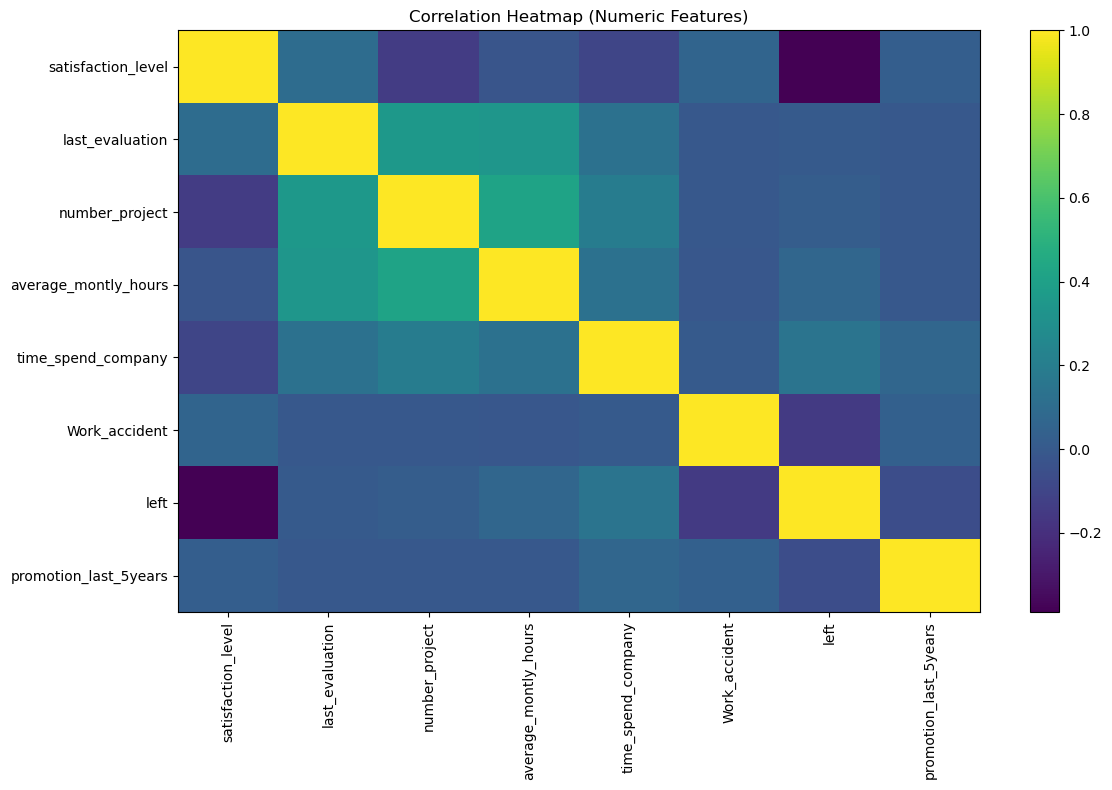

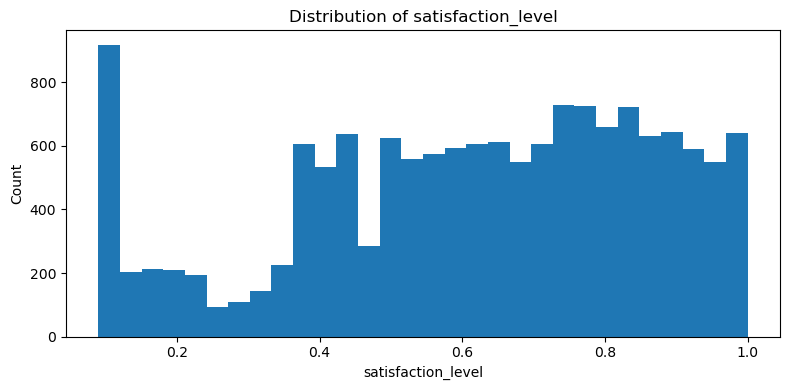

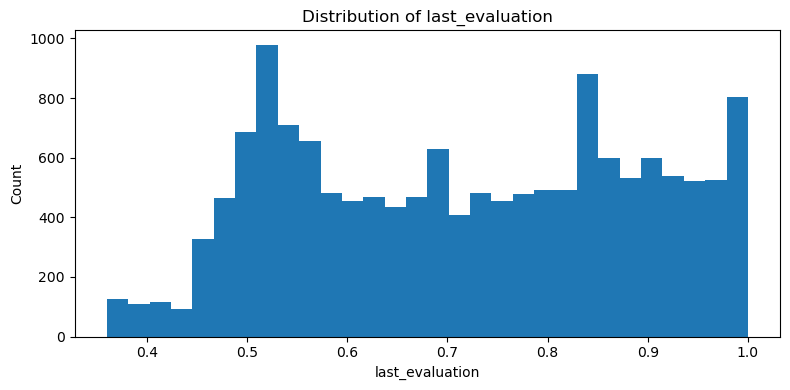

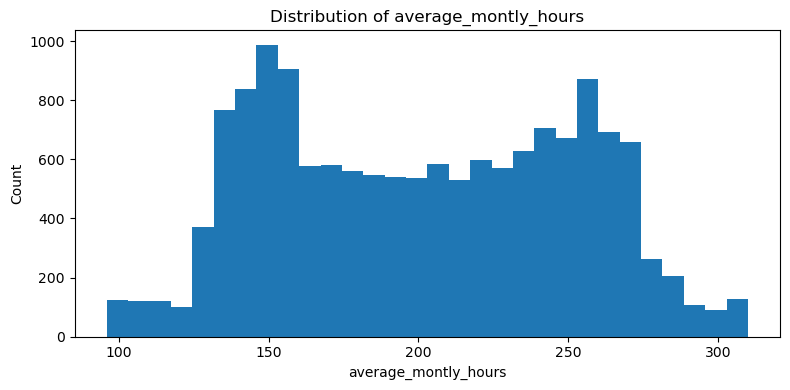

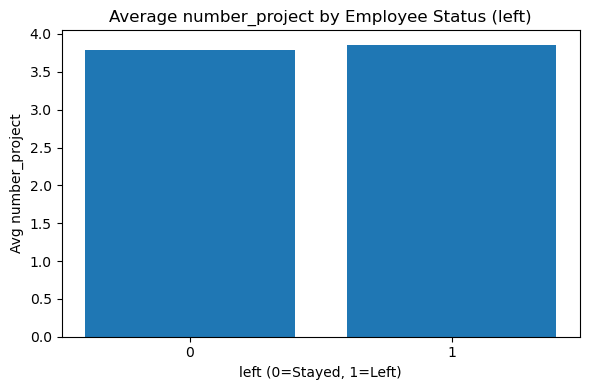

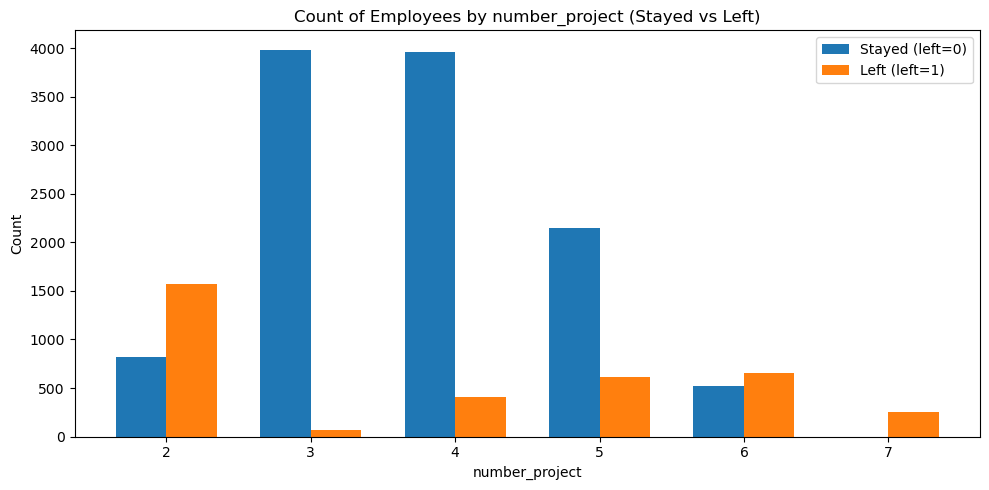

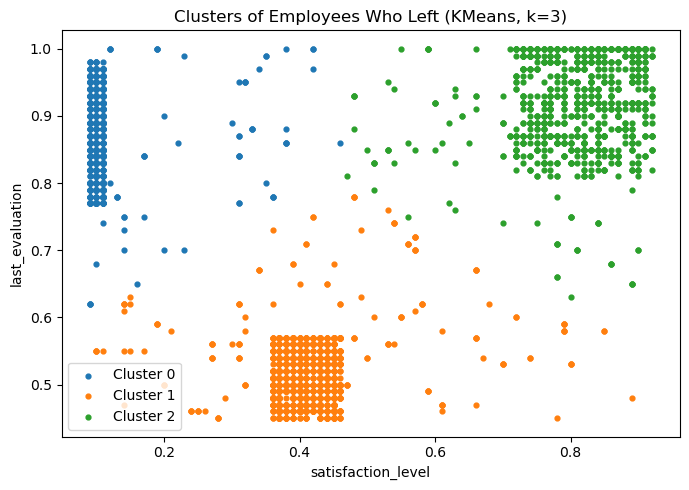


Cluster Means (Leavers):
          satisfaction_level  last_evaluation
cluster                                     
0.0                0.111321         0.870884
1.0                0.412304         0.517265
2.0                0.808031         0.916415

5-Fold CV (with SMOTE inside folds) — Mean Scores:
            model   roc_auc  precision    recall        f1  accuracy
1  random_forest  0.991924   0.982402  0.956949  0.969496  0.985666
2     grad_boost  0.988223   0.928725  0.934195  0.931439  0.967247
0         logreg  0.822048   0.528325  0.691619  0.598876  0.779397

MODEL: logreg
ROC AUC: 0.8205

Confusion Matrix:
 [[1836  450]
 [ 201  513]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9013    0.8031    0.8494      2286
           1     0.5327    0.7185    0.6118       714

    accuracy                         0.7830      3000
   macro avg     0.7170    0.7608    0.7306      3000
weighted avg     0.8136    0.7830    0.7929     

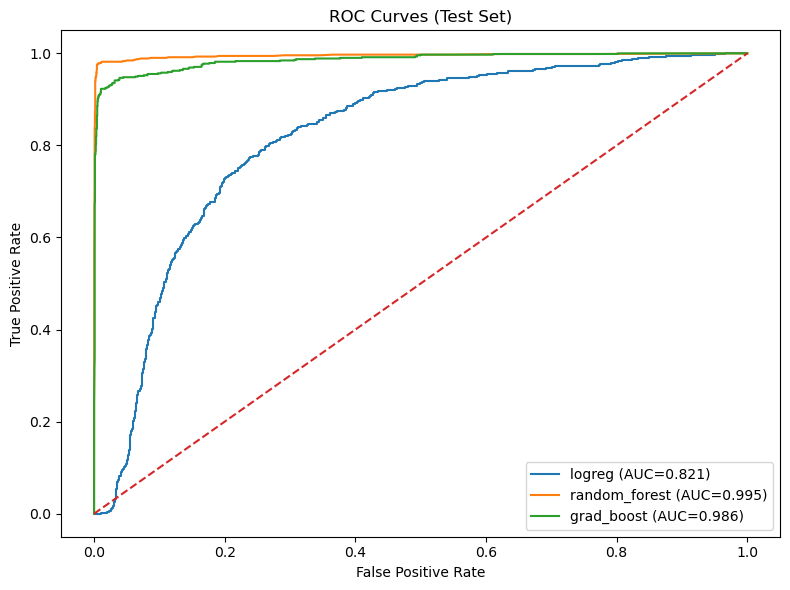


Test Metrics Summary:
            model   roc_auc    tn   fp   fn   tp
1  random_forest  0.995220  2270   16   16  698
2     grad_boost  0.985819  2230   56   50  664
0         logreg  0.820539  1836  450  201  513

BEST MODEL: random_forest

Risk Zone Counts:
 risk_zone
NaN                     2412
Safe (Green)             416
High Risk (Red)          133
Low Risk (Yellow)         26
Medium Risk (Orange)      13
Name: count, dtype: int64

Retention strategies by zone:

Safe (Green):
 - Maintain engagement: regular check-ins, recognition, steady growth opportunities
 - Keep workload balanced and continue standard performance feedback cycles

Low Risk (Yellow):
 - Manager 1:1s to identify early dissatisfaction signals
 - Targeted learning paths, role clarity, small workload adjustments

Medium Risk (Orange):
 - Deep-dive conversation: workload, role fit, growth, compensation expectations
 - Action plan: adjust projects, mentorship, internal mobility options, training

High Risk (Red):


In [116]:
run_full_pipeline("employee_turnover_data.csv")